In [56]:
import torch 
import torchvision
import torch.nn as nn 
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd 
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt 
import numpy as np 
import os 
from pathlib import Path 

In [57]:
## Device Configuration ## 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [58]:
## Preprocessing ##

In [7]:
os.getcwd()

'c:\\Users\\isaac\\Documents\\Personal_Projects\\AI\\image_class\\Scripts'

In [8]:
## Split the dataset ##

In [9]:
root_dir=r"C:\Users\isaac\Documents\Personal_Projects\AI\image_class\Scripts\MSTAR-PublicMixedTargets-CD1\MSTAR_PUBLIC_MIXED_TARGETS_CD1\15_DEG\COL2\SCENE1"
root = os.listdir(root_dir)

In [ ]:
# Image and Label Extraction 
"""
The goal of this algorithm is to extract the images and labels for the training and test sets. 
This will create a combined dataframe of images and labels to feed as the inputs for the neural network. 
The classes are: 2S1, BRDM_2, D7, SLICY, T62, ZIL131, ZSU_23_4. 


"""



# Training (ONLY WORKS IF COL1 is treated as training set)

"""
root1 = Path(r'C:\Users\isaac\Documents\Personal_Projects\AI\image_class\Scripts\MSTAR-PublicMixedTargets-CD1\MSTAR_PUBLIC_MIXED_TARGETS_CD1\15_DEG\COL1\SCENE1\BTR_60')
training_images = []
training_labels = []

for img_path in root1.rglob('*.JPG'):
    header_path = img_path.with_suffix(".003")

    label = None
    with open(header_path, 'r', encoding='latin-1') as f:
        for line in f:
            if line.startswith('TargetType'):
                label = line.split('=')[1].strip()
                break

    if label is None:
        continue

    tr_img = Image.open(img_path)
    tr_img = tr_img.resize((128,128))
    training_images.append(np.array(tr_img))
    training_labels.append(label)


# Test 
test_labels = []
test_images = []

for cls in root:
    cls_dir = Path(os.path.join(root_dir, cls))
    for img_path in cls_dir.rglob('*.JPG'):
        img = Image.open(img_path)
        img = img.resize((128,128))
        test_images.append(np.array(img))
        test_labels.append(cls)
        
"""
   
# Ignore for general purpose
                   

In [ ]:
training_labels # Ignore

['btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',
 'btr60_transport',


In [ ]:
# Extract Images and Labels

labels = []
images = []

for cls in root:
    cls_dir = Path(os.path.join(root_dir, cls))
    for img_path in cls_dir.rglob("*.JPG"):
        img = Image.open(img_path)
        img = img.resize((128,128))
        images.append(np.array(img))
        labels.append(cls)

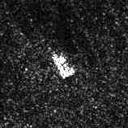

In [21]:
img # Test image retrieval 

In [22]:
X = np.array(images)
y = np.array(labels)

In [23]:
X = X / 255 # Normalize
X = X[...,np.newaxis]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

X = torch.tensor(X, dtype=torch.float32)  # (1917, 128, 128, 1)
X = X.permute(0, 3, 1, 2)                 # (1917, 1, 128, 128) PyTorch expects (N, C, H, W)
y = torch.tensor(y, dtype=torch.long)

In [24]:
# Train Test Split 

batch_size = 128

x_train, x_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [60]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6], dtype=int64)

In [ ]:
class MStarCNN(nn.Module):
    def __init__(self): 
        super().__init__() 
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32,
                            kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.2),
            nn.Conv2d(in_channels=32, out_channels=64,
                            kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.2),
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 7)
        )
    
    def forward(self,x): 
        return self.model(x)

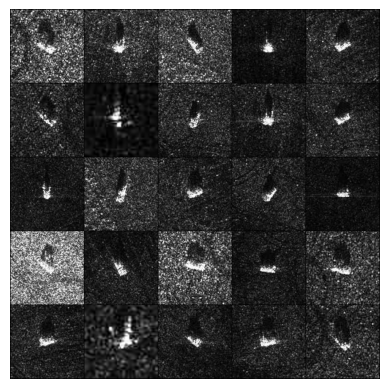

In [26]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
images

plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:25], normalize=True, padding=1, nrow=5).numpy(), (1, 2, 0)))
plt.axis('off')
plt.show()

In [27]:
model = MStarCNN().to(device)

In [ ]:
# Hyperparamters

num_epochs = 10
learning_rate = 0.0003
weight_decay = 0.001
torch.manual_seed(283) # Set Seed for reproducibility 

weights = compute_class_weight('balanced', classes=np.array([0,1,2,3,4,5,6]), y=y_train.numpy())
weights = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [ ]:
# Training plus Validation

train_loss_list = []
all_preds  = []
all_labels = []

for epoch in range(num_epochs): 
    train_loss= 0
    model.train() 

    for images, labels in train_loader: 
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)

        loss = criterion(output, labels)
        optimizer.zero_grad() 
        loss.backward()
        optimizer.step()
        train_loss+= loss.item()
    
    train_loss_list.append(train_loss/len(train_loader))
    print(f"Training Loss = {train_loss_list[-1]}")

    # Validation 

    model.eval() 

    correct = 0 
    total = 0 

    with torch.no_grad():
        for images, labels in test_loader: 
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs,1)
            correct += (predicted==labels).sum().item() 
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_acc = correct / total
    print(f"epochs:{epoch+1} | Val_acc:{val_acc}") 

Training Loss = 0.09907259256578982
epochs:1 | Val_acc:0.9348958333333334
Training Loss = 0.05295610443378488
epochs:2 | Val_acc:0.9661458333333334
Training Loss = 0.036176275151471295
epochs:3 | Val_acc:0.9817708333333334
Training Loss = 0.021907548885792494
epochs:4 | Val_acc:0.9817708333333334
Training Loss = 0.018725082123031218
epochs:5 | Val_acc:0.9817708333333334
Training Loss = 0.014886273226390282
epochs:6 | Val_acc:0.984375
Training Loss = 0.01245002937503159
epochs:7 | Val_acc:0.9869791666666666
Training Loss = 0.009805128870842358
epochs:8 | Val_acc:0.9921875
Training Loss = 0.009360623351919154
epochs:9 | Val_acc:0.9869791666666666
Training Loss = 0.009338202575842539
epochs:10 | Val_acc:0.9921875


In [ ]:
# Model Accuracy after 10 epochs: 99%

In [ ]:
cm = confusion_matrix(all_labels, all_preds) # Classification 

In [78]:
import seaborn as sns

Text(50.722222222222214, 0.5, 'Predicted Labels')

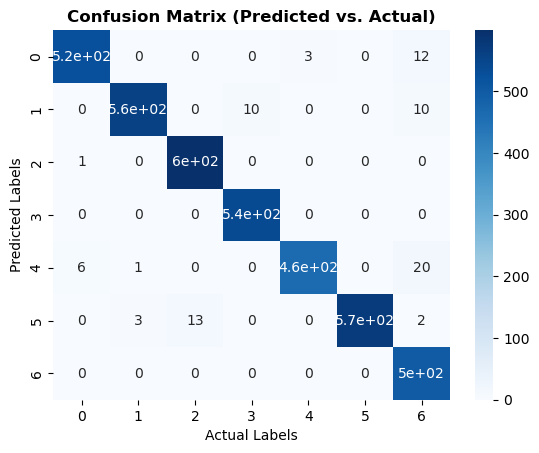

In [79]:
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix (Predicted vs. Actual)", fontweight="bold")
plt.xlabel("Actual Labels")
plt.ylabel("Predicted Labels")

In [ ]:
""" 
The plot is fairly good until label 6. We see the most misclassifications here. 
The possible reason is due to the similiarity of scattering patterns. 
Potential Solutions: 

- Class weights - added changes
- Epoch changes - added changes
- Learning rate - added changes
- Data Augmentation (Image Rotation)

"""

' \nThe plot is fairly good until label 6. We see the most misclassifications here. \nThe possible reason is due to the similiarity of scattering patterns. \nPotential Solutions: \n\n- Class weights\n- Epoch changes\n- Data Augmentation (Image Rotation)\n\n'

In [80]:
# Do the changes work? - The classification is much better with the changes. 

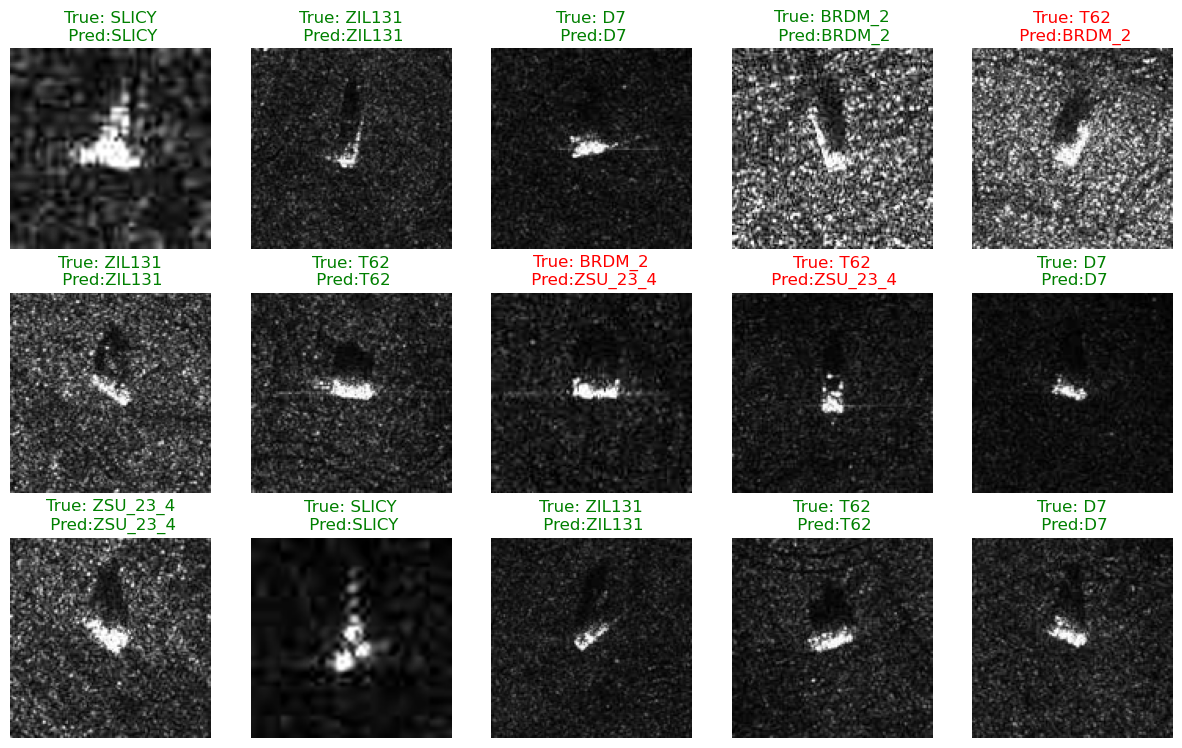

In [ ]:
# Visual of Predictions 

fig, axes = plt.subplots(3,5, figsize=(15,9))

for i, ax in enumerate(axes.flat): 
    img = x_test[i].squeeze().numpy()
    true = le.classes_[all_labels[i]]
    pred = le.classes_[all_preds[i]]
    color = "green" if true == pred else "red"
    ax.imshow(img,cmap="gray")
    ax.set_title(f"True: {true}\n Pred:{pred}", color=color)
    ax.axis("off")

plt.show()